# **03 - Random Forest**

Random Forest regressors on `y = log1p(target)` for the Jeonse (deposit) and Wolse (monthly rent) tracks. Predictions are back-transformed with `expm1` and evaluated in original wones on TEST (2025).

| model_id | Description |
|---|---|
| `rf_static` | categoricals, `log_area`, `floor`, `floor_missing`, `building_age`; no time feature |
| `rf_time` | `rf_static` plus `t` (months since 2022-01) |
| `rf_detrended` | a log-linear month trend `y = a + b*t` is fit on TRAIN, a static forest predicts the residual, and the trend is added back (extrapolated linearly) |

**Why trees struggle with a level shift.** A forest predicts averages of target values seen in TRAIN, so it cannot output a value outside the TRAIN range and cannot extrapolate a trend: every 2025 row with `t` beyond the last TRAIN month falls in the same leaves as the last TRAIN months. `rf_detrended` tests whether separating the trend from the structure helps.

**Pipeline.** `OrdinalEncoder` (unknown category -> -1) inside a scikit-learn `Pipeline`; `floor` keeps its NaN (handled natively by the forest) together with `floor_missing`. Hyperparameters (`n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`) are tuned with `RandomizedSearchCV` (`n_iter=20`) over the 3-fold expanding-window folds, scored by WAPE on the original scale. TEST is used only for the final evaluation.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'rent_model').exists())
sys.path.insert(0, str(ROOT / 'src'))

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

from rent_model import config
from rent_model.data import load_clean
from rent_model.features import build_features, build_target, select_track
from rent_model.forest import feature_columns, fit_predict, to_original, tune, wape_scorer
from rent_model.io import save_run
from rent_model.metrics import all_metrics, wape
from rent_model.splits import expanding_window_folds, temporal_split

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width', 170)
plt.rcParams['figure.dpi'] = 100
print('Random seed:', config.RANDOM_SEED)

Random seed: 42


## Data and splits

In [2]:
df = load_clean()
VARIANTS = {'rf_static': 'static', 'rf_time': 'time', 'rf_detrended': 'detrended'}
TUNING_ROWS = 60_000   # TRAIN subsample used for tuning only; final models are fit on the full TRAIN

data = {}
for track in config.TRACKS:
    train, test = temporal_split(select_track(df, track))
    sub = train.sample(TUNING_ROWS, random_state=config.RANDOM_SEED)
    data[track] = dict(
        train=train, test=test, target=config.TRACKS[track]['target'],
        X_train=build_features(train, track, include_time=True), y_train=build_target(train, track),
        X_test=build_features(test, track, include_time=True), y_test=test[config.TRACKS[track]['target']],
        X_sub=build_features(sub, track, include_time=True), y_sub=build_target(sub, track),
        folds_sub=expanding_window_folds(sub))
    print(f"{track}: train {len(train):,} rows, test {len(test):,} rows; tuning subsample {len(sub):,} rows; "
          f"fold sizes (train, valid) {[(len(a), len(b)) for a, b in data[track]['folds_sub']]}")

jeonse: train 138,848 rows, test 37,935 rows; tuning subsample 60,000 rows; fold sizes (train, valid) [(21768, 13892), (35660, 12980), (48640, 11360)]
wolse: train 152,714 rows, test 57,829 rows; tuning subsample 60,000 rows; fold sizes (train, valid) [(19904, 13621), (33525, 12472), (45997, 14003)]


The tuning subsample is a seeded random sample of exactly 60,000 TRAIN rows per track (drawn with `RANDOM_SEED`); the 3 expanding-window folds are rebuilt on it, so validation blocks still lie after their training blocks. The final models are fit on the full TRAIN.

## Hyperparameter tuning (RandomizedSearchCV, n_iter=20)

In [3]:
tuning = {}
for track in config.TRACKS:
    d = data[track]
    for model_id, variant in VARIANTS.items():
        tuning[(track, model_id)] = tune(variant, d['X_sub'], d['y_sub'], d['folds_sub'], n_iter=20)

rows = []
for (track, model_id), (best, table) in tuning.items():
    top = table.iloc[0]
    rows.append({'track': track, 'model_id': model_id, **best,
                 'cv_wape_mean': top['cv_wape_mean'], 'cv_wape_std': top['cv_wape_std'],
                 'worst_candidate_cv_wape': table['cv_wape_mean'].max()})
display(pd.DataFrame(rows).set_index(['track', 'model_id']))

n_estimators  max_depth  min_samples_leaf  max_features  cv_wape_mean  cv_wape_std  worst_candidate_cv_wape
track  model_id                                                                                                                 
jeonse rf_static              300         20                 1        0.7000       18.9588       0.8191                  24.3395
       rf_time                300         20                 1        0.7000       18.9559       0.1299                  25.1304
       rf_detrended           300         20                 1        0.7000       18.6323       1.5481                  23.7156
wolse  rf_static              300         20                 5        0.5000       43.6683       2.3559                  44.8923
       rf_time                300         20                 5        0.5000       44.1091       2.6912                  45.3900
       rf_detrended           300         20                 5        0.5000       43.0036       2.3417                  44.2155

**Interpretation.** Tuning matters: in Jeonse the best `rf_static` candidate has a CV WAPE of 18.9588% against 24.3395% for the worst candidate. All six searches select `n_estimators=300` and `max_depth=20`; `min_samples_leaf` is 1 in Jeonse and 5 in Wolse, and `max_features` is 0.7 in Jeonse and 0.5 in Wolse. `n_estimators=300` is the upper edge of its grid and `min_samples_leaf=1` is the lower edge, so a larger forest or deeper trees might still gain a little. Within a track the three variants have close CV scores (Jeonse 18.9588%, 18.9559% and 18.6323%; Wolse 43.6683%, 44.1091% and 43.0036%), and the fold-to-fold standard deviation is between 0.1299 and 2.6912 points.

## Fit on the full TRAIN and evaluate on TEST (2025)

In [4]:
fitted, preds, rows = {}, {}, []
for track in config.TRACKS:
    d = data[track]
    for model_id, variant in VARIANTS.items():
        best, table = tuning[(track, model_id)]
        model, pred = fit_predict(variant, best, d['X_train'], d['y_train'], d['X_test'])
        fitted[(track, model_id)], preds[(track, model_id)] = model, pred
        meta = {'variant': variant, 'params': best, 'cv_wape_mean': float(table.loc[0, 'cv_wape_mean']),
                'tuning_rows': TUNING_ROWS, 'features': feature_columns(variant != 'static'),
                'fit_period': '2022-01-01..2024-12-31', 'eval_period': '2025'}
        if variant == 'detrended':
            meta.update(trend_slope_log_per_month=float(model.slope_), trend_intercept_log=float(model.intercept_))
        save_run(track, model_id, d['y_test'], pred, meta=meta, context=d['test'][['district_name', 'contract_date']])
        rows.append({'track': track, 'model_id': model_id, **all_metrics(d['y_test'].to_numpy(), pred)})
metrics = pd.DataFrame(rows)

def last_run(track, model_id):
    return json.loads((config.METRICS_DIR / f'{track}__{model_id}.json').read_text(encoding='utf-8'))[-1]

cols = ['n', 'wape_pct', 'mae', 'mdape_pct', 'median_bias_pct', 'aggregate_bias_pct', 'rmse_log', 'r2_log']
for track in config.TRACKS:
    table = metrics[metrics['track'] == track].set_index('model_id')[cols]
    for ref_id in ['baseline_district_type_area', 'ridge_time_rich']:
        table.loc[f'(ref) {ref_id}'] = [last_run(track, ref_id)[c] for c in cols]
    print(f'TEST metrics - {track}')
    display(table)
for track in config.TRACKS:
    m = fitted[(track, 'rf_detrended')]
    print(f"{track}: detrended trend slope {m.slope_:.5f} log points per month "
          f"(= {np.expm1(m.slope_) * 100:.2f}% per month), intercept {m.intercept_:.4f}")

TEST metrics - jeonse


,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log
model_id,,,,,,,,
rf_static,"37,935.0000",18.9266,"8,530.3653",14.2058,-7.3262,-9.6371,0.2950,0.8475
rf_time,"37,935.0000",17.9051,"8,069.9658",13.6291,-5.1635,-6.4563,0.2912,0.8514
rf_detrended,"37,935.0000",17.9091,"8,071.7713",13.5941,5.2498,2.7507,0.3003,0.8419
(ref) baseline_district_type_area,"37,935.0000",27.2510,"12,282.2552",20.3822,-4.7619,-10.2899,0.3909,0.7322
(ref) ridge_time_rich,"37,935.0000",23.0944,"10,408.8488",17.9308,-8.2595,-10.6128,0.3428,0.7941


TEST metrics - wolse


,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log
model_id,,,,,,,,
rf_static,"57,829.0000",45.9594,34.4532,35.9485,-16.8654,-23.7873,0.7004,0.3342
rf_time,"57,829.0000",46.3507,34.7465,37.1325,-17.2760,-24.0149,0.7053,0.3248
rf_detrended,"57,829.0000",45.7560,34.3007,35.7110,-16.1919,-23.1224,0.6997,0.3355
(ref) baseline_district_type_area,"57,829.0000",46.9591,35.2026,32.5301,-7.4074,-14.5804,0.7641,0.2075
(ref) ridge_time_rich,"57,829.0000",49.0983,36.8062,39.1765,-20.2776,-28.9682,0.7336,0.2695


jeonse: detrended trend slope 0.00583 log points per month (= 0.58% per month), intercept 10.1794
wolse: detrended trend slope 0.00039 log points per month (= 0.04% per month), intercept 3.9268


**Interpretation (Jeonse).** The forest improves clearly on the linear models: TEST WAPE is 18.93% (`rf_static`), 17.91% (`rf_time`) and 17.91% (`rf_detrended`), against 23.09% for `ridge_time_rich` and 27.25% for the naive baseline; `r2_log` rises from 0.7941 to 0.8514 (`rf_time`). The variants differ mainly in bias. `rf_static` underpredicts (median bias -7.33%, aggregate -9.64%). Adding `t` reduces the bias (-5.16% and -6.46%), and the detrended forest flips its sign (median bias +5.25%, aggregate +2.75%), so the linearly extrapolated trend overshoots in Jeonse. The fitted trend is 0.58% per month.

**Interpretation (Wolse).** The forest gains little: 45.96% (`rf_static`), 46.35% (`rf_time`) and 45.76% (`rf_detrended`), against 49.10% for `ridge_time_rich` and 46.96% for the naive baseline. The log-scale fit is better than the baseline (`rmse_log` 0.6997 against 0.7641 for `rf_detrended`), but the bias is far larger (median bias -16.19% against -7.41%, aggregate -23.12% against -14.58%). The fitted trend in the Wolse TRAIN period is only 0.04% per month, so the detrended variant adds almost nothing over `rf_static`.

## Does the forest follow the 2025 level? Monthly median, predicted vs actual

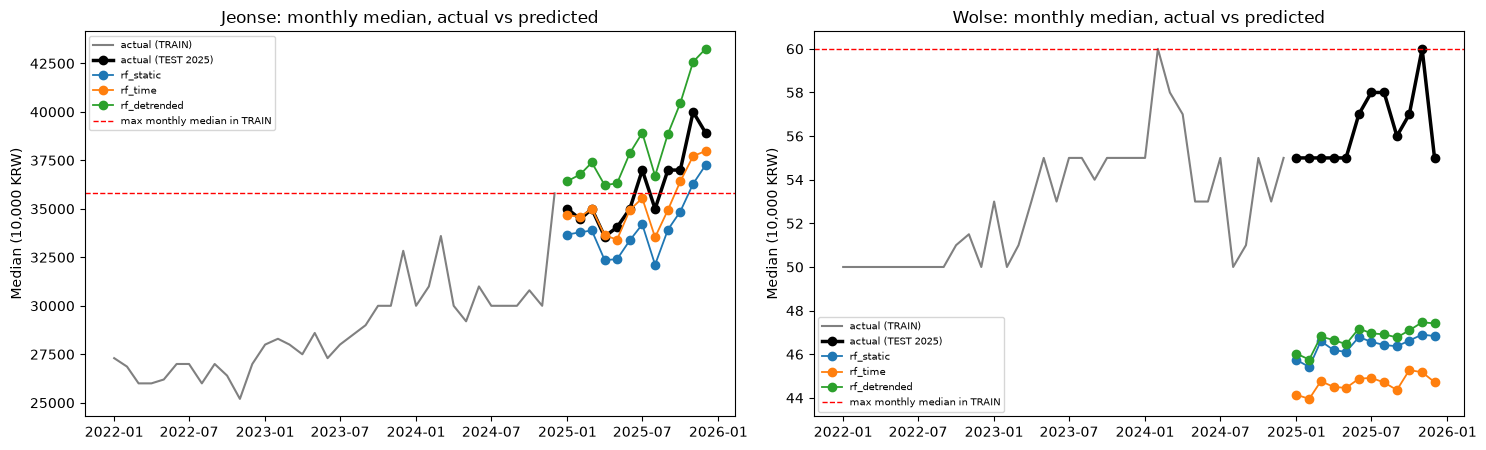

jeonse: max monthly median in TRAIN = 35,800.00; max single TRAIN target = 750,000.00


,actual,rf_static,rf_time,rf_detrended
contract_date,,,,
2025-01-01,"35,000.0000","33,675.7634","34,673.0857","36,427.8717"
2025-02-01,"34,466.0000","33,791.6661","34,587.1304","36,776.1325"
2025-03-01,"35,000.0000","33,884.6037","35,011.7418","37,390.2898"
2025-04-01,"33,569.0000","32,363.0201","33,636.5126","36,224.3947"
2025-05-01,"34,050.0000","32,399.9998","33,413.4986","36,313.7650"
2025-06-01,"35,000.0000","33,379.8306","34,941.9648","37,874.8899"
2025-07-01,"37,000.0000","34,199.0596","35,551.1583","38,915.5620"
2025-08-01,"35,000.0000","32,116.9796","33,532.5031","36,698.6290"
2025-09-01,"37,000.0000","33,922.9523","34,941.9821","38,862.5351"


,actual_2025_max_month,rf_static_max_month,rf_time_max_month,rf_detrended_max_month,rf_static_max_pred,rf_time_max_pred,rf_detrended_max_pred
0,"40,000.0000","37,252.2597","37,977.9207","43,250.6482","489,222.5290","565,920.1889","551,363.7940"


wolse: max monthly median in TRAIN = 60.00; max single TRAIN target = 4,000.00


,actual,rf_static,rf_time,rf_detrended
contract_date,,,,
2025-01-01,55.0000,45.7417,44.1423,46.0292
2025-02-01,55.0000,45.4173,43.9539,45.7554
2025-03-01,55.0000,46.6031,44.7631,46.8139
2025-04-01,55.0000,46.1886,44.5050,46.6498
2025-05-01,55.0000,46.1093,44.4558,46.4646
2025-06-01,57.0000,46.7879,44.8793,47.1799
2025-07-01,58.0000,46.5688,44.9166,46.9567
2025-08-01,58.0000,46.4252,44.7063,46.9133
2025-09-01,56.0000,46.3660,44.3614,46.7718


,actual_2025_max_month,rf_static_max_month,rf_time_max_month,rf_detrended_max_month,rf_static_max_pred,rf_time_max_pred,rf_detrended_max_pred
0,60.0000,46.9030,45.2749,47.4654,"1,272.8517","1,020.0215","1,250.0640"


In [5]:
month = lambda frame: frame['contract_date'].dt.to_period('M').dt.to_timestamp()
monthly = {}
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for ax, track in zip(axes, config.TRACKS):
    d = data[track]
    actual_train = d['y_train'].pipe(np.expm1).groupby(month(d['train'])).median()
    actual_test = d['y_test'].groupby(month(d['test'])).median()
    table = pd.DataFrame({'actual': actual_test})
    for model_id in VARIANTS:
        table[model_id] = pd.Series(preds[(track, model_id)], index=d['test'].index).groupby(month(d['test'])).median()
    monthly[track] = table
    train_max = actual_train.max()
    ax.plot(actual_train.index, actual_train.values, color='gray', lw=1.5, label='actual (TRAIN)')
    ax.plot(table.index, table['actual'], color='black', lw=2.5, marker='o', label='actual (TEST 2025)')
    for model_id in VARIANTS:
        ax.plot(table.index, table[model_id], marker='o', lw=1.3, label=model_id)
    ax.axhline(train_max, color='red', ls='--', lw=1, label='max monthly median in TRAIN')
    ax.set_title(f'{track.capitalize()}: monthly median, actual vs predicted')
    ax.set_ylabel('Median (10,000 KRW)'); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

for track in config.TRACKS:
    d = data[track]
    actual_train = d['y_train'].pipe(np.expm1).groupby(month(d['train'])).median()
    print(f"{track}: max monthly median in TRAIN = {actual_train.max():,.2f}; "
          f"max single TRAIN target = {np.expm1(d['y_train'].max()):,.2f}")
    summary = pd.DataFrame({
        'actual_2025_max_month': [monthly[track]['actual'].max()],
        **{f'{m}_max_month': [monthly[track][m].max()] for m in VARIANTS},
        **{f'{m}_max_pred': [preds[(track, m)].max()] for m in VARIANTS}})
    display(monthly[track]); display(summary)

**Interpretation.** Jeonse: the maximum monthly median in TRAIN is 35,800, and the forests do predict monthly medians above that value in 2025 (`rf_static` up to 37,252, `rf_time` up to 37,978), so the monthly median is not capped at the TRAIN maximum; the 2025 mix of districts, types and areas moves it. The cap exists at the level of single predictions: the largest TRAIN target is 750,000 and the largest predictions are 489,223 to 565,920. What the forests do is lag behind the actual level: in November the actual median is 40,000 against 36,292 (`rf_static`) and 37,723 (`rf_time`), and `rf_static` is below `rf_time` in every month. `rf_detrended` follows the rise but overshoots (43,251 against 38,925 in December).

Wolse: the maximum monthly median in TRAIN is 60.00 and the actual 2025 medians reach 60.00 (November), but no variant gets above 47.4654 (`rf_detrended`); `rf_time` stays between 43.9539 and 45.2749. None of them follows the 2025 level, and `rf_time` is the lowest of the three variants.

## Bias by quarter (TEST 2025)

In [6]:
def bias_table(track, kind):
    d = data[track]; q = d['test']['contract_date'].dt.quarter
    out = {}
    for model_id in VARIANTS:
        frame = pd.DataFrame({'y': d['y_test'].to_numpy(), 'p': preds[(track, model_id)], 'q': q.to_numpy()})
        if kind == 'median':
            out[model_id] = frame.groupby('q').apply(lambda g: np.median((g['p'] - g['y']) / g['y']) * 100, include_groups=False)
        else:
            out[model_id] = frame.groupby('q').apply(lambda g: (g['p'].sum() - g['y'].sum()) / g['y'].sum() * 100, include_groups=False)
    return pd.DataFrame(out)

for track in config.TRACKS:
    print(f'{track}: median bias % by quarter'); display(bias_table(track, 'median'))
    print(f'{track}: aggregate bias % by quarter'); display(bias_table(track, 'aggregate'))

jeonse: median bias % by quarter


,rf_static,rf_time,rf_detrended
q,,,
1,-5.5871,-3.3990,4.5946
2,-6.2819,-4.4887,5.6148
3,-7.6917,-5.4781,5.9815
4,-10.1241,-7.7590,4.7410


jeonse: aggregate bias % by quarter


,rf_static,rf_time,rf_detrended
q,,,
1,-6.8897,-3.7839,3.1825
2,-8.8019,-5.6538,3.0206
3,-10.3489,-7.0589,3.1426
4,-13.0657,-9.8757,1.5182


wolse: median bias % by quarter


,rf_static,rf_time,rf_detrended
q,,,
1,-15.4620,-15.8381,-14.8265
2,-16.0554,-16.3813,-15.4065
3,-18.9550,-19.5187,-18.2936
4,-17.1244,-17.6689,-16.3176


wolse: aggregate bias % by quarter


,rf_static,rf_time,rf_detrended
q,,,
1,-21.1346,-21.2375,-20.5919
2,-23.9280,-24.0496,-23.3054
3,-26.1363,-26.6466,-25.4532
4,-24.0222,-24.1910,-23.1894


**Interpretation.** In Jeonse the bias of `rf_static` grows through 2025: the median bias goes from -5.59% in Q1 to -10.12% in Q4 and the aggregate bias from -6.89% to -13.07%. With `t` the bias is smaller but follows the same pattern (-3.40% in Q1 and -7.76% in Q4 for the median). The detrended forest has a stable positive bias (median +4.59% in Q1, +5.98% in Q3 and +4.74% in Q4; aggregate from +3.18% to +1.52%). So the static and time forests lose accuracy as the level rises during the year, and the detrended forest over-corrects. In Wolse every variant underpredicts in every quarter: the median bias is between -14.83% and -19.52% and the aggregate bias between -20.59% and -26.65%, with no systematic change that a time feature could capture.

## Permutation importance (TEST subsample, best model per track)

In [7]:
PERM_ROWS = 5_000
best_id = {}
for track in config.TRACKS:
    d = data[track]
    m = metrics[metrics['track'] == track].set_index('model_id')
    best_id[track] = m['wape_pct'].idxmin()
    variant = VARIANTS[best_id[track]]
    cols_ = feature_columns(variant != 'static')
    idx = d['X_test'].sample(PERM_ROWS, random_state=config.RANDOM_SEED).index
    X_perm = d['X_test'].loc[idx, cols_]
    y_perm = np.log1p(d['y_test'].loc[idx])
    result = permutation_importance(fitted[(track, best_id[track])], X_perm, y_perm, scoring=wape_scorer,
                                    n_repeats=5, random_state=config.RANDOM_SEED, n_jobs=1)
    table = pd.DataFrame({'wape_increase_pts': result.importances_mean, 'std': result.importances_std},
                         index=cols_).sort_values('wape_increase_pts', ascending=False)
    print(f"{track}: {best_id[track]} - increase in TEST WAPE (percentage points) when a column is permuted; "
          f"{PERM_ROWS:,} TEST rows, 5 repeats")
    display(table)

jeonse: rf_time - increase in TEST WAPE (percentage points) when a column is permuted; 5,000 TEST rows, 5 repeats


,wape_increase_pts,std
log_area,34.0877,0.3991
building_age,14.4212,0.2597
district_name,13.9406,0.3225
building_type,10.0123,0.2702
floor,2.2863,0.0911
floor_missing,0.2659,0.0255
contract_type,0.2382,0.0472
renewal_right_used,0.0723,0.0129
t,-0.0000,0.0000


wolse: rf_detrended - increase in TEST WAPE (percentage points) when a column is permuted; 5,000 TEST rows, 5 repeats


,wape_increase_pts,std
log_area,14.2911,0.3867
building_type,4.2515,0.1945
district_name,3.2692,0.2151
building_age,3.1288,0.4298
contract_type,1.7991,0.1011
floor,1.7293,0.2181
floor_missing,0.1897,0.0161
renewal_right_used,0.1627,0.0328
t,0.0049,0.0019


**Interpretation.** In Jeonse (`rf_time`) permuting `log_area` raises TEST WAPE by 34.0877 points, `building_age` by 14.4212, `district_name` by 13.9406 and `building_type` by 10.0123, while `floor` adds 2.2863. The increase for `t` is 0.0000: all 2025 values of `t` lie beyond the last TRAIN month, so shuffling them among TEST rows does not change which side of any split they take, and the forest has no information about how the level moves during 2025. In Wolse (`rf_detrended`) `log_area` also dominates (14.2911 points), followed by `building_type` (4.2515), `district_name` (3.2692) and `building_age` (3.1288); `t` is 0.0049 because in this variant it only enters through the trend.

## Partial dependence: log_area and building_age (best model per track)

jeonse log_area: grid [20.79, 115.9] -> mean prediction [13697.95, 72536.07]


jeonse building_age: grid [2.0, 40.0] -> mean prediction [59155.57, 31542.55]


wolse log_area: grid [15.0, 84.99] -> mean prediction [37.66, 88.42]


wolse building_age: grid [2.0, 38.0] -> mean prediction [69.63, 50.54]


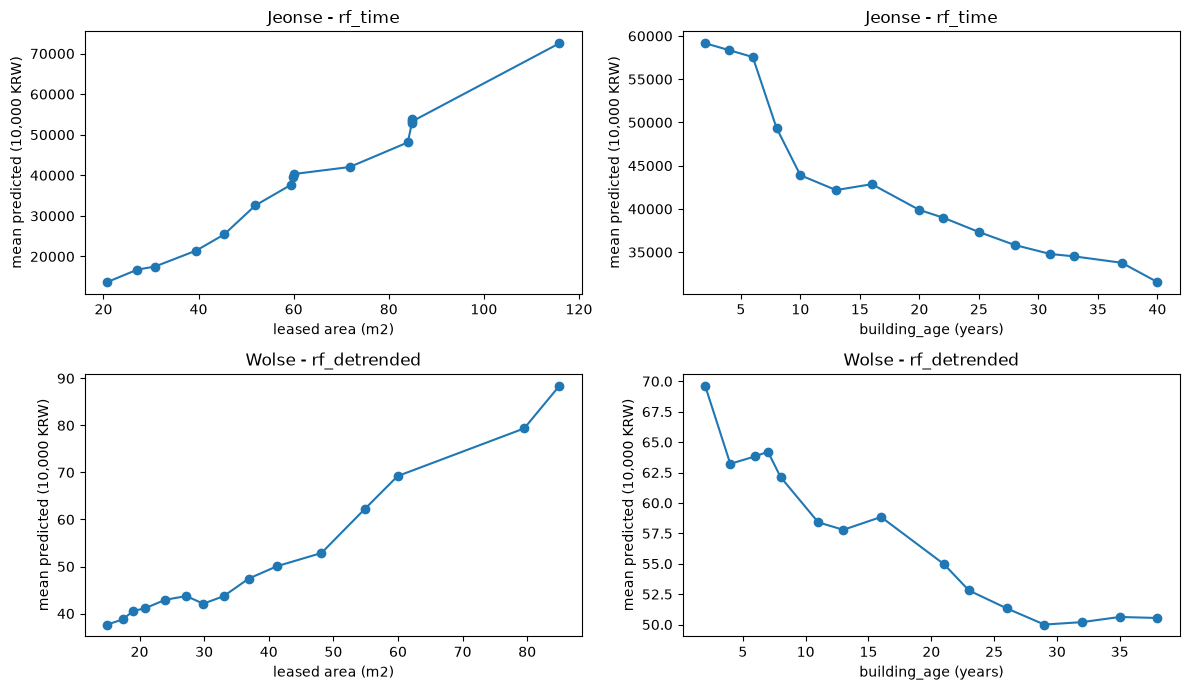

In [8]:
def partial_dependence(model, X, column, variant, n_grid=15):
    cols_ = feature_columns(variant != 'static')
    grid = np.unique(np.quantile(X[column], np.linspace(0.05, 0.95, n_grid)))
    values = []
    for g in grid:
        Xg = X[cols_].copy(); Xg[column] = g
        values.append(to_original(model.predict(Xg)).mean())
    return grid, np.array(values)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for r, track in enumerate(config.TRACKS):
    d = data[track]; variant = VARIANTS[best_id[track]]
    X_pd = d['X_test'].sample(3_000, random_state=config.RANDOM_SEED)
    for c, column in enumerate(['log_area', 'building_age']):
        grid, values = partial_dependence(fitted[(track, best_id[track])], X_pd, column, variant)
        x = np.exp(grid) if column == 'log_area' else grid
        axes[r, c].plot(x, values, marker='o')
        axes[r, c].set_xlabel('leased area (m2)' if column == 'log_area' else 'building_age (years)')
        axes[r, c].set_ylabel('mean predicted (10,000 KRW)')
        axes[r, c].set_title(f'{track.capitalize()} - {best_id[track]}')
        print(f"{track} {column}: grid {np.round(x[[0, -1]], 2).tolist()} -> mean prediction {np.round(values[[0, -1]], 2).tolist()}")
plt.tight_layout(); plt.show()

**Interpretation.** The partial dependence curves are in the plots above; the printed end points describe them. In Jeonse the mean prediction goes from 13,697.95 at 20.79 m2 to 72,536.07 at 115.9 m2, and falls with age from 59,155.57 at 2 years to 31,542.55 at 40 years. In Wolse it goes from 37.66 at 15.0 m2 to 88.42 at 84.99 m2 and from 69.63 at 2 years to 50.54 at 38 years. Larger and newer units are predicted at higher prices in both tracks. Partial dependence averages over the observed mix of other features, so it shows an association and not a causal effect of age or area.

## Summary

In [9]:
summary = metrics.pivot(index='model_id', columns='track', values=['wape_pct', 'median_bias_pct', 'aggregate_bias_pct']).loc[list(VARIANTS)]
display(summary)

wape_pct         median_bias_pct          aggregate_bias_pct         
track          jeonse   wolse          jeonse    wolse             jeonse    wolse
model_id                                                                          
rf_static     18.9266 45.9594         -7.3262 -16.8654            -9.6371 -23.7873
rf_time       17.9051 46.3507         -5.1635 -17.2760            -6.4563 -24.0149
rf_detrended  17.9091 45.7560          5.2498 -16.1919             2.7507 -23.1224

## Conclusion

- **Jeonse.** The forests are the best models so far: 17.91% WAPE for `rf_time` and `rf_detrended`, against 23.09% for the best linear model and 27.25% for the best baseline.
- **Can trees follow the 2025 shift?** Only partly. `t` does not extrapolate (its permutation importance on TEST is 0.0000), but `rf_time` still ends closer to the 2025 level than `rf_static` (median bias -5.16% against -7.33%). Even so, the bias of the static and time forests grows during 2025, and the detrended forest overshoots (+5.25%). In Wolse none of the variants follows the level (median bias between -16.19% and -17.28%).
- **Wolse.** WAPE is 45.76% to 46.35%, a small gain over the naive baseline (46.96%) with a much larger bias, so the missing piece is the level in 2025, not the structure among districts, types and areas.